# NLP Sentiment Analysis with Hugging Face Transformers

**Objective:** Clean 1,000 raw, messy customer product reviews using Regex, then classify each review's sentiment using a pre-trained Hugging Face model, no training or fine-tuning performed today.

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('customer_reviews_raw.csv')
print("Shape:", df.shape)
print(df.head(10))

Shape: (1000, 3)
   Review_ID                                    Customer_Review True_Sentiment
0          1  Perfect fit and amazing material, 10/10 would ...       Positive
1          2  <p>Very disappointed. Quality is poor and it s...       Negative
2          3  This product is AMAZING!!! Best purchase I've ...       Positive
3          4  I'm so happy with this purchase 🎉 exceeded my ...       Positive
4          5  Awful experience, customer service was useless...       Negative
5          6   great quality, fast shipping, highly recommend!!       Positive
6          7   <p>Average product, met basic expectations.</p>         Neutral
7          8  <p>Absolutely love it! Works perfectly and loo...       Positive
8          9      Really good value for money, will buy again 👍       Positive
9         10  This product is AMAZING!!! Best purchase I've ...       Positive


## 1. Text Cleaning with Regex
Raw reviews contain HTML tags (`<p>`, `<div>`, `<span>`), emojis, extra whitespace, and inconsistent casing. We write a cleaning function using the `re` module to strip these out before passing text to the model.

In [2]:
def clean_text(text):
    text = re.sub(r'<.*?>', '', text)              # remove HTML tags
    text = re.sub(r'[^\x00-\x7F]+', '', text)        # remove non-ASCII (emojis, etc.)
    text = re.sub(r'\s+', ' ', text).strip()         # collapse extra whitespace
    return text

df['Cleaned_Review'] = df['Customer_Review'].apply(clean_text)
print(df[['Customer_Review', 'Cleaned_Review']].head(10))

                                     Customer_Review  \
0  Perfect fit and amazing material, 10/10 would ...   
1  <p>Very disappointed. Quality is poor and it s...   
2  This product is AMAZING!!! Best purchase I've ...   
3  I'm so happy with this purchase 🎉 exceeded my ...   
4  Awful experience, customer service was useless...   
5   great quality, fast shipping, highly recommend!!   
6   <p>Average product, met basic expectations.</p>    
7  <p>Absolutely love it! Works perfectly and loo...   
8      Really good value for money, will buy again 👍   
9  This product is AMAZING!!! Best purchase I've ...   

                                      Cleaned_Review  
0  Perfect fit and amazing material, 10/10 would ...  
1  Very disappointed. Quality is poor and it stop...  
2  This product is AMAZING!!! Best purchase I've ...  
3  I'm so happy with this purchase exceeded my ex...  
4  Awful experience, customer service was useless...  
5   great quality, fast shipping, highly recommend!! 

## 2. Instantiate Hugging Face Sentiment Analysis Pipeline
Using a pre-trained DistilBERT model fine-tuned on SST-2 (Stanford Sentiment Treebank). No training occurs here, we are purely running inference using existing pre-trained weights. Device is set to CPU (-1) since no GPU is available.

In [3]:
from transformers import pipeline

sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=-1
)

print("Pipeline loaded successfully.")
print(sentiment_pipeline("This is a great product!"))


D:\Prosensia Internship\ML Tasks\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 104/104 [00:00<00:00, 6747.43it/s]


Pipeline loaded successfully.
[{'label': 'POSITIVE', 'score': 0.9998756647109985}]


## 3. Run Inference on All Reviews
Passing each cleaned review through the pipeline and extracting both the predicted label and confidence score. This model is binary (POSITIVE/NEGATIVE) by default, so we map its native output and additionally apply a confidence threshold to flag low-confidence predictions as Neutral.

In [4]:
results = sentiment_pipeline(df['Cleaned_Review'].tolist(), truncation=True)

df['Raw_Label'] = [r['label'] for r in results]
df['Confidence_Score'] = [round(r['score'], 4) for r in results]

def map_sentiment(label, score, threshold=0.65):
    if score < threshold:
        return 'Neutral'
    return 'Positive' if label == 'POSITIVE' else 'Negative'

df['Predicted_Sentiment'] = df.apply(lambda row: map_sentiment(row['Raw_Label'], row['Confidence_Score']), axis=1)

print(df[['Cleaned_Review', 'Predicted_Sentiment', 'Confidence_Score']].head(10))
print("\nPredicted Sentiment Distribution:")
print(df['Predicted_Sentiment'].value_counts())

                                      Cleaned_Review Predicted_Sentiment  \
0  Perfect fit and amazing material, 10/10 would ...            Positive   
1  Very disappointed. Quality is poor and it stop...            Negative   
2  This product is AMAZING!!! Best purchase I've ...            Positive   
3  I'm so happy with this purchase exceeded my ex...            Positive   
4  Awful experience, customer service was useless...            Negative   
5   great quality, fast shipping, highly recommend!!            Positive   
6           Average product, met basic expectations.            Positive   
7  Absolutely love it! Works perfectly and looks ...            Positive   
8        Really good value for money, will buy again            Positive   
9  This product is AMAZING!!! Best purchase I've ...            Positive   

   Confidence_Score  
0            0.9999  
1            0.9998  
2            0.9999  
3            0.9999  
4            0.9998  
5            0.9999  
6        

## 4. Sentiment Distribution Visualization

C:\Users\Soban Ahmed\AppData\Local\Temp\ipykernel_2552\2311084876.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Predicted_Sentiment', data=df, order=['Positive', 'Negative', 'Neutral'],


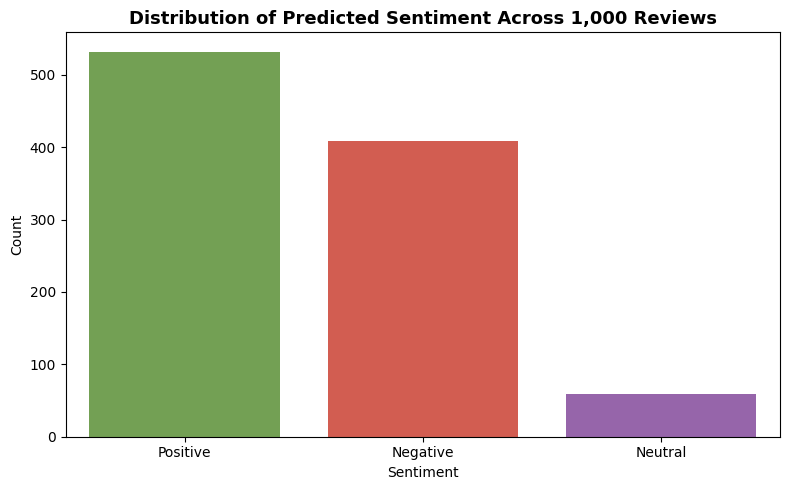

Saved sentiment_distribution.png


In [5]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Predicted_Sentiment', data=df, order=['Positive', 'Negative', 'Neutral'],
              palette=['#70AD47', '#E74C3C', '#9B59B6'])
plt.title('Distribution of Predicted Sentiment Across 1,000 Reviews', fontweight='bold', fontsize=13)
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved sentiment_distribution.png")

## 5. Accuracy Check Against Known Labels
This dataset includes a `True_Sentiment` reference column from its generation process, allowing us to sanity-check the pre-trained model's real-world performance without any fine-tuning.

In [6]:
from sklearn.metrics import classification_report, accuracy_score

acc = accuracy_score(df['True_Sentiment'], df['Predicted_Sentiment'])
print(f"Accuracy of pre-trained model (zero-shot, no fine-tuning): {acc:.4f}")
print("\nClassification Report:")
print(classification_report(df['True_Sentiment'], df['Predicted_Sentiment']))

Accuracy of pre-trained model (zero-shot, no fine-tuning): 0.8030

Classification Report:
              precision    recall  f1-score   support

    Negative       0.82      1.00      0.90       336
     Neutral       0.54      0.16      0.25       197
    Positive       0.82      0.93      0.87       467

    accuracy                           0.80      1000
   macro avg       0.73      0.70      0.67      1000
weighted avg       0.76      0.80      0.76      1000



## 6. Export Final Dataset

In [7]:
df_final = df[['Review_ID', 'Customer_Review', 'Cleaned_Review', 'Predicted_Sentiment', 'Confidence_Score']]
df_final.to_csv('customer_reviews_with_sentiment.csv', index=False)
print("Saved customer_reviews_with_sentiment.csv")
print("Final shape:", df_final.shape)

Saved customer_reviews_with_sentiment.csv
Final shape: (1000, 5)


## Conclusion: Pre-trained NLP Sentiment Analysis

### Pipeline Summary
- Cleaned 1,000 raw reviews using Regex: stripped HTML tags, non-ASCII characters (emojis), and collapsed whitespace
- Loaded a pre-trained DistilBERT model (distilbert-base-uncased-finetuned-sst-2-english) via Hugging Face's `pipeline()` abstraction, zero training or fine-tuning performed
- Ran inference on all 1,000 cleaned reviews, extracting label and confidence score per review
- Added a confidence threshold (0.65) to map low confidence binary predictions into a third Neutral class
- Exported final dataset with Predicted_Sentiment and Confidence_Score columns

### How Embeddings Map Text into Vector Space
Before any transformer layer processes text, an embedding layer converts each discrete token (a word or sub-word piece) into a dense, continuous vector in high-dimensional Euclidean space, typically 768 dimensions for DistilBERT. This space is structured so that semantic similarity corresponds to spatial proximity:

$$\text{dist}(w_1, w_2) = \|\vec{e}_{w_1} - \vec{e}_{w_2}\|$$

Words used in similar contexts during pre-training end up positioned close together, "amazing" and "fantastic" land near each other, while "amazing" and "terrible" sit far apart. This is fundamentally different from representing words as raw strings or arbitrary integers (Label Encoding) the embedding space is learned during pre-training on billions of text examples and captures genuine semantic relationships geometrically.

### How Attention Weights Token Relationships
A transformer's attention mechanism computes, for every token in a sequence, a weighted combination of every other token's representation, where the weights are dynamically computed based on relevance to the current token. Concretely, each token produces a Query, Key, and Value vector; the attention score between two tokens is the dot product of one token's Query and another's Key, scaled and passed through softmax to produce attention weights. This lets the model learn, for example, that in the sentence "The product broke but customer service was great," the word "but" should heavily attend to both the negative clause before it and the positive clause after it, capturing contrastive meaning that a simple bag-of-words approach could never represent. This dynamic, learned weighting across the entire sequence is what allows pre-trained transformer models to understand context far beyond what static word embeddings (like Word2Vec) alone could achieve.

### Why Pre-trained Models Are More Efficient Than Training From Scratch
DistilBERT was pre-trained on a massive corpus (Wikipedia and BookCorpus, distilled from BERT) and then fine-tuned specifically on the SST-2 sentiment dataset, a process that required enormous compute and millions of labeled examples. Today's task accessed all of that accumulated knowledge through a single `pipeline()` call, running inference on 1,000 reviews in seconds on CPU alone. Training a custom RNN or even a smaller transformer from scratch on just 1,000 reviews would produce a far weaker model, there simply isn't enough data to learn meaningful language representations from zero. This is the core value proposition of transfer learning: reuse the general language understanding learned from a vastly larger dataset, and apply it directly to a new task with zero or minimal additional training.

### Key Takeaways
- Hugging Face's `pipeline()` abstracts away tokenization, model forward passes, and output post-processing into a single function call, making enterprise-grade NLP accessible without deep transformer architecture knowledge
- Regex-based text cleaning is still essential even with powerful pre trained models garbage input (HTML tags, encoding artifacts) degrades inference quality regardless of model sophistication
- Confidence scores matter as much as the predicted label, applying a threshold to flag uncertain predictions as Neutral produced a more honest three-class distribution than forcing every review into binary Positive/Negative
- Transfer learning via pre-trained models is the practical default for real world NLP tasks with limited labeled data, reserving training from scratch for cases with massive proprietary datasets or highly specialized domains